In [1]:
import os, sys

NB_DIR = os.getcwd()
QL_DIR = os.path.dirname(NB_DIR)
sys.path.append(QL_DIR)

import importlib
import numpy as np
import matplotlib.pyplot as plt
import runner

importlib.reload(runner)

PROJECT_ROOT = os.path.abspath(os.getcwd())
RUNS_DIR = os.path.join(PROJECT_ROOT, "runs")
QSTAR_DIR = os.path.join(RUNS_DIR, "qstar")
QL_SHORT_RUNS_DIR = os.path.join(RUNS_DIR, "ql_short")
QL_LONG_RUNS_DIR = os.path.join(RUNS_DIR, "ql_long")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")

os.makedirs(QSTAR_DIR, exist_ok=True)
os.makedirs(QL_SHORT_RUNS_DIR, exist_ok=True)
os.makedirs(QL_LONG_RUNS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

ENV_NAME = "frozenlake"
MAP_NAME = "4x4"
SLIPPERY = True

SEEDS = list(range(10))
SHORT_GAMMAS = [0.1, 0.9]
ALL_GAMMAS = [0.1, 0.3, 0.6, 0.9]
M_VALUES = [1, 4, 8, 16, 32]

SHORT_STEPS = 1100
LONG_STEPS = 10000
BATCH_LONG = 32
BASELINE_LONG = 1
SAMPLES_PER_PAIR = 1

ALPHA = 0.1
ALPHA_MODE = "global"
ALPHA_BETA = 1.0
ALPHA_TAU = 20000
USE_EXACT_BELLMAN = False

STRIDE_SHORT = 100
STRIDE_LONG = 200
FORCE_RERUN = False

COLOR_MAP_M = {
    1: "brown",
    4: "orange",
    8: "green",
    16: "red",
    32: "blue",
}

COLOR_MAP_GAMMA = {
    0.1: "green",
    0.3: "red",
    0.6: "blue",
    0.9: "brown",
}

def gamma_tag(gamma):
    return str(gamma).replace(".", "p")

def env_tag(env_name, map_name):
    return f"{env_name}_{map_name}" if env_name == "frozenlake" else env_name

def qstar_file(gamma):
    return os.path.join(QSTAR_DIR, f"Qstar_dp_{env_tag(ENV_NAME, MAP_NAME)}_gamma{gamma_tag(gamma)}.npy")

def ql_file(out_root, gamma, m, seed):
    mode_tag = "exact" if USE_EXACT_BELLMAN else f"K{SAMPLES_PER_PAIR}"
    tag = f"ql_{env_tag(ENV_NAME, MAP_NAME)}_m{m}_{mode_tag}_gamma{gamma_tag(gamma)}_seed{seed}"
    return os.path.join(out_root, f"{tag}.npz")

def load_qstar(gamma):
    path = qstar_file(gamma)
    if os.path.exists(path):
        return np.load(path)

    tag, Q_star = runner.run_compute_Qstar_stationary_dp(
        ENV_NAME,
        map_name=MAP_NAME,
        slippery=SLIPPERY,
        gamma=gamma,
        seed=0,
        out_root=QSTAR_DIR,
    )

    path = os.path.join(QSTAR_DIR, f"{tag}.npy")
    return np.load(path)

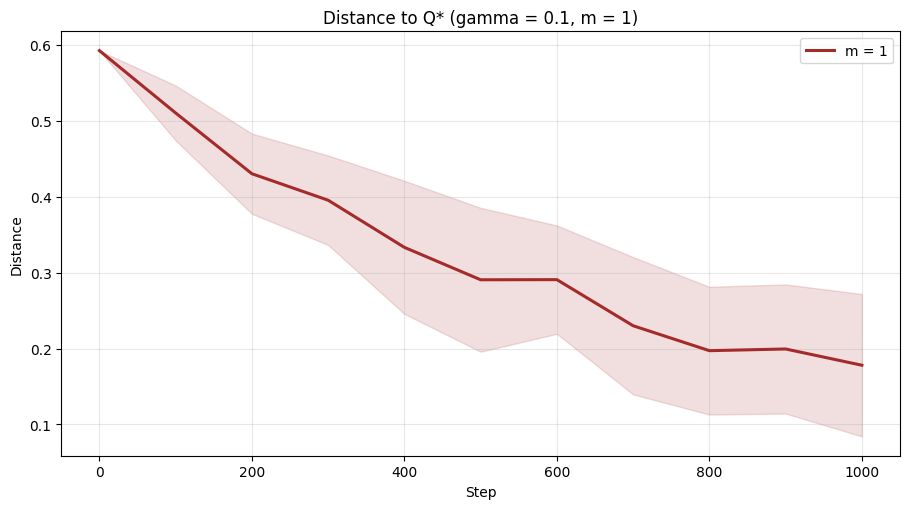

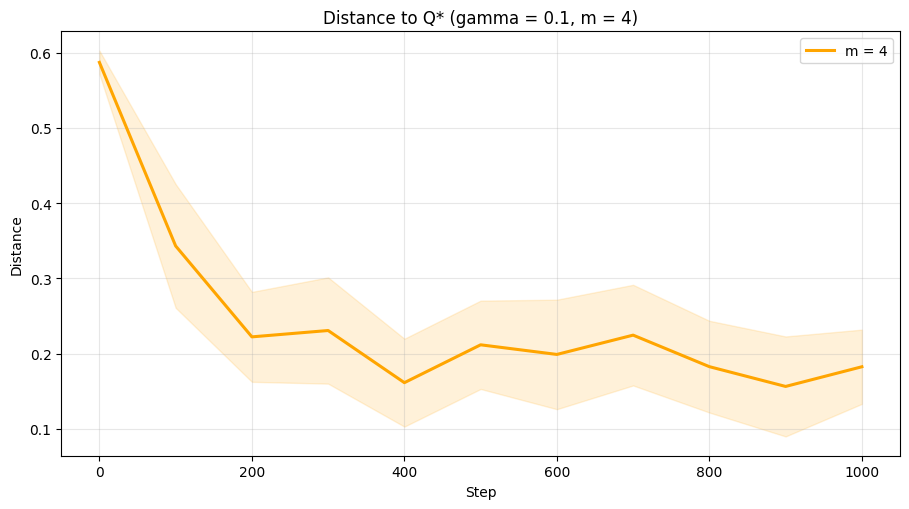

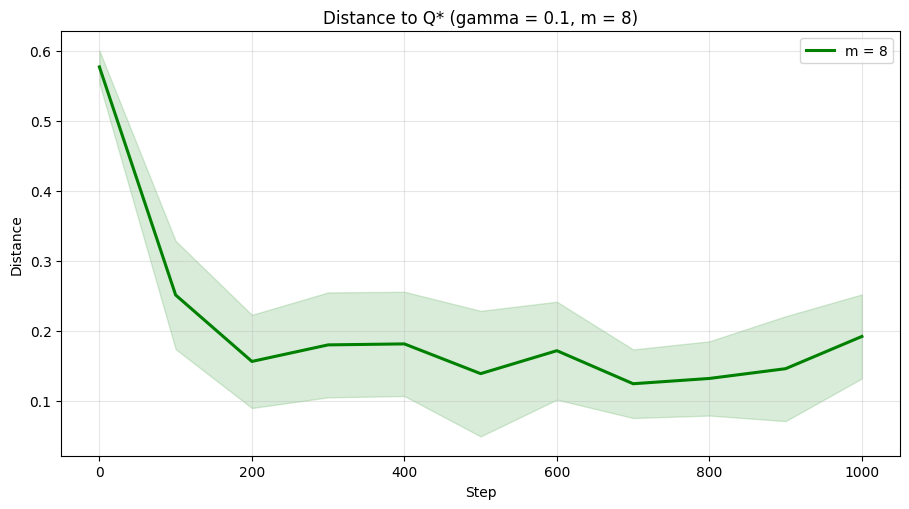

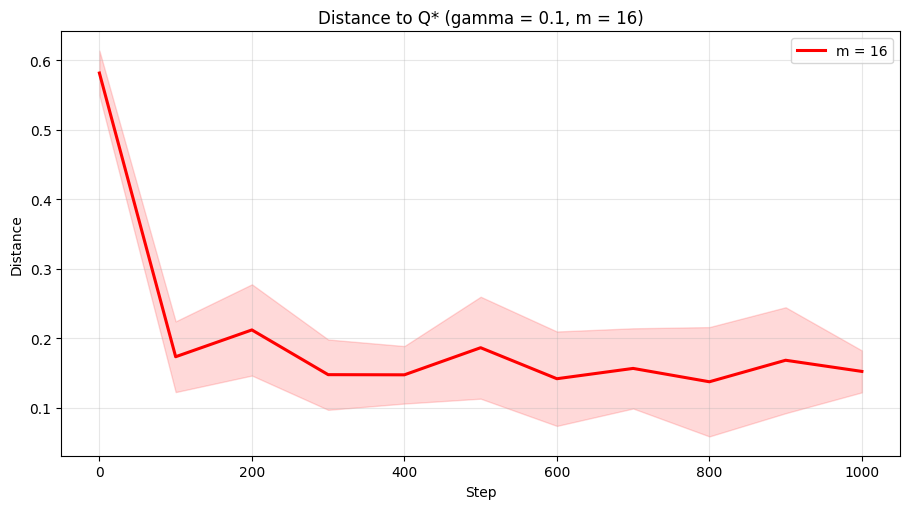

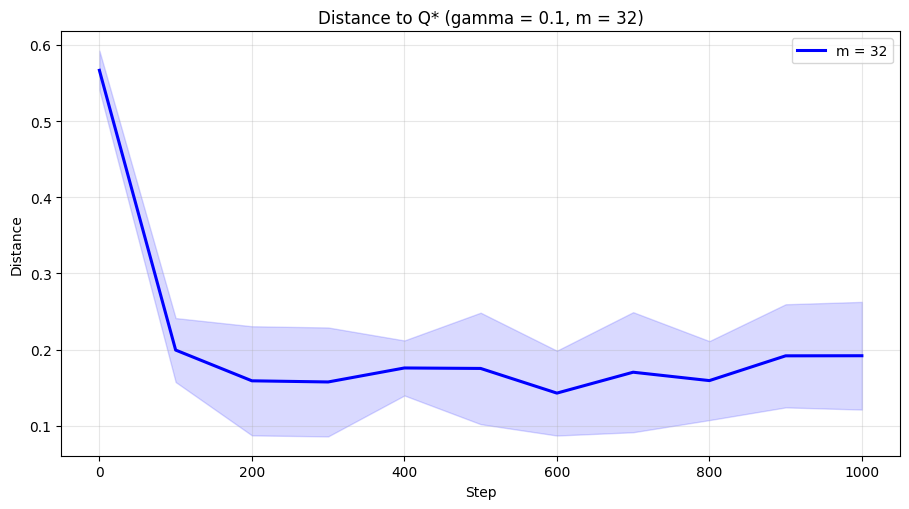

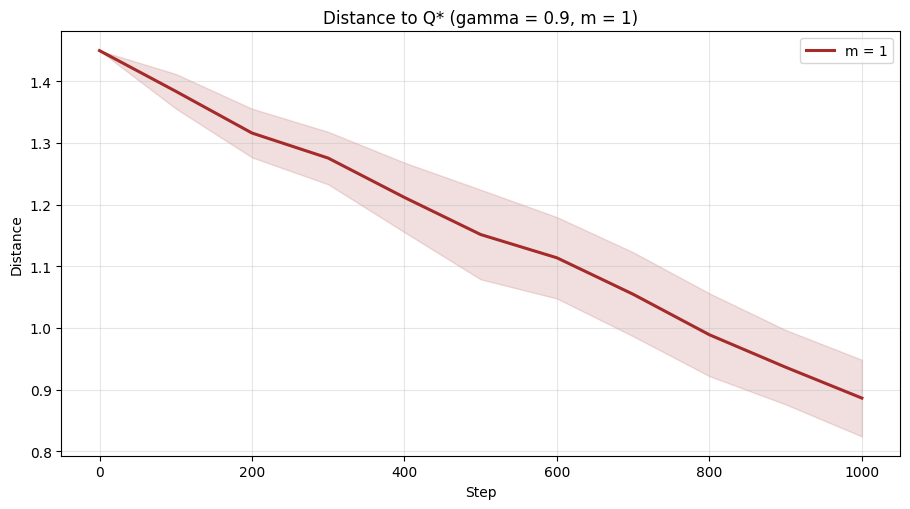

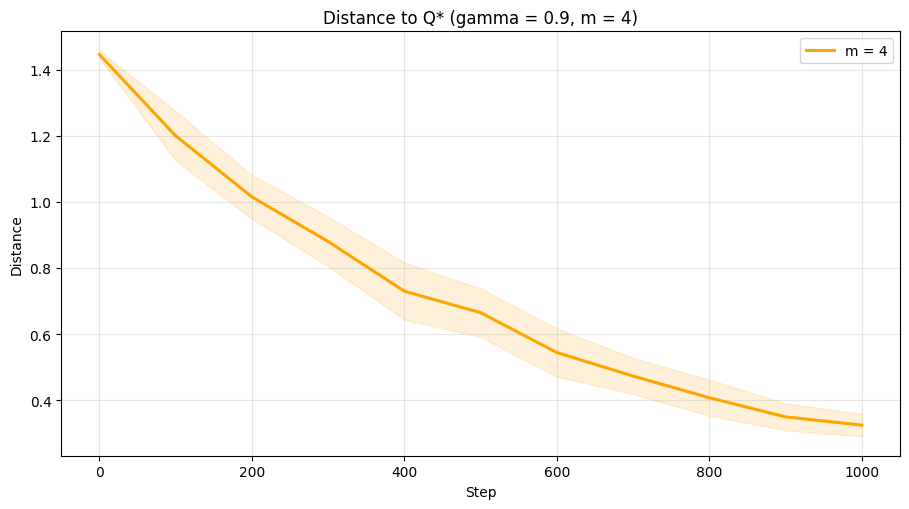

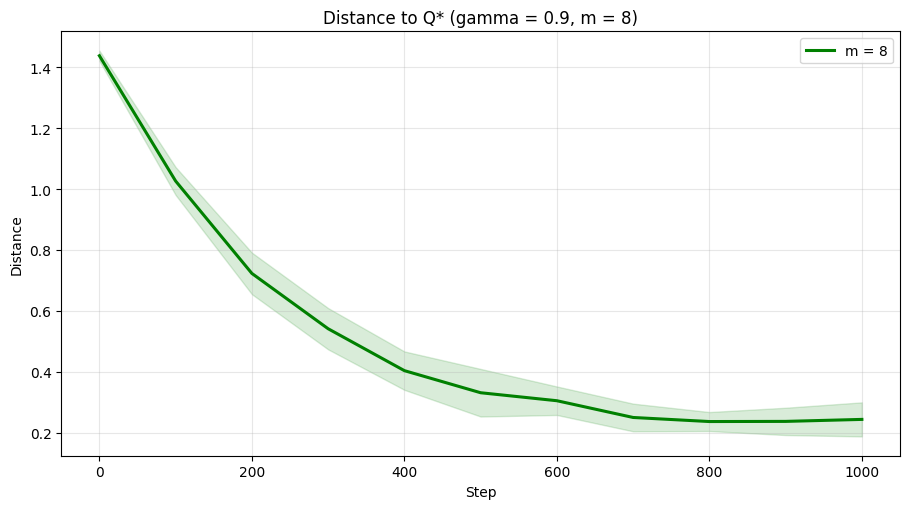

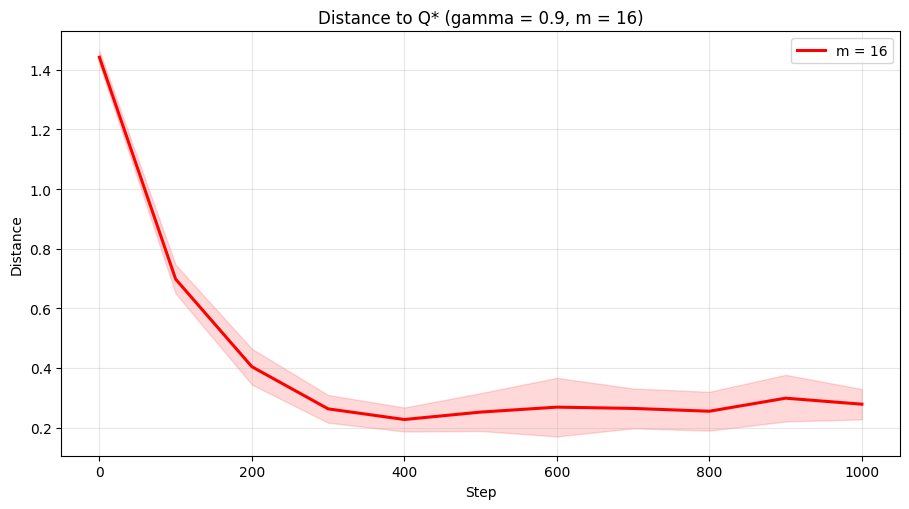

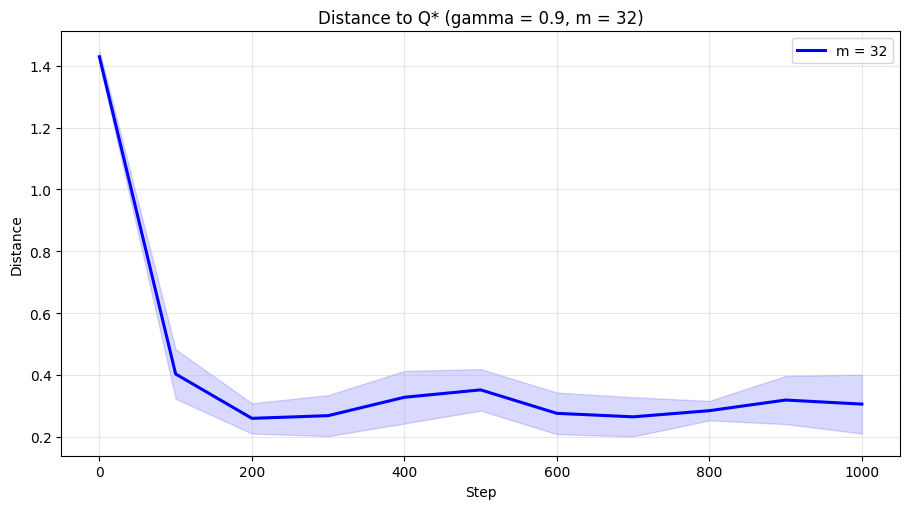

In [2]:
short_runs = {}

for gamma in SHORT_GAMMAS:
    Q_star = load_qstar(gamma)
    short_runs[gamma] = {}

    for m in M_VALUES:
        curves = []

        for seed in SEEDS:
            path = ql_file(QL_SHORT_RUNS_DIR, gamma, m, seed)

            if FORCE_RERUN or not os.path.exists(path):
                runner.run_uniform_batch(
                    ENV_NAME,
                    map_name=MAP_NAME,
                    slippery=SLIPPERY,
                    seed=seed,
                    steps=SHORT_STEPS,
                    batch_size=m,
                    samples_per_pair=SAMPLES_PER_PAIR,
                    alpha=ALPHA,
                    gamma=gamma,
                    Q_star=Q_star,
                    alpha_mode=ALPHA_MODE,
                    alpha_beta=ALPHA_BETA,
                    alpha_tau=ALPHA_TAU,
                    use_exact_bellman=USE_EXACT_BELLMAN,
                    out_root=QL_SHORT_RUNS_DIR,
                )

            data = np.load(path, allow_pickle=True)
            curves.append(np.asarray(data["dist_to_Qstar"], dtype=float))

        arr = np.stack(curves, axis=0)
        short_runs[gamma][m] = {
            "mean": arr.mean(axis=0),
            "std": arr.std(axis=0),
        }

for gamma in SHORT_GAMMAS:
    for m in M_VALUES:
        mean_y = short_runs[gamma][m]["mean"]
        std_y = short_runs[gamma][m]["std"]
        x = np.arange(len(mean_y))

        plt.figure(figsize=(9.2, 5.2))
        plt.plot(
            x[::STRIDE_SHORT],
            mean_y[::STRIDE_SHORT],
            color=COLOR_MAP_M[m],
            linewidth=2.2,
            label=f"m = {m}",
        )
        plt.fill_between(
            x[::STRIDE_SHORT],
            mean_y[::STRIDE_SHORT] - std_y[::STRIDE_SHORT],
            mean_y[::STRIDE_SHORT] + std_y[::STRIDE_SHORT],
            color=COLOR_MAP_M[m],
            alpha=0.15,
        )
        plt.title(f"Distance to Q* (gamma = {gamma}, m = {m})")
        plt.xlabel("Step")
        plt.ylabel("Distance")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()

        filename = os.path.join(FIGURES_DIR, f"ql_batch_size_gamma{gamma}_m{m}.png")
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        plt.show()

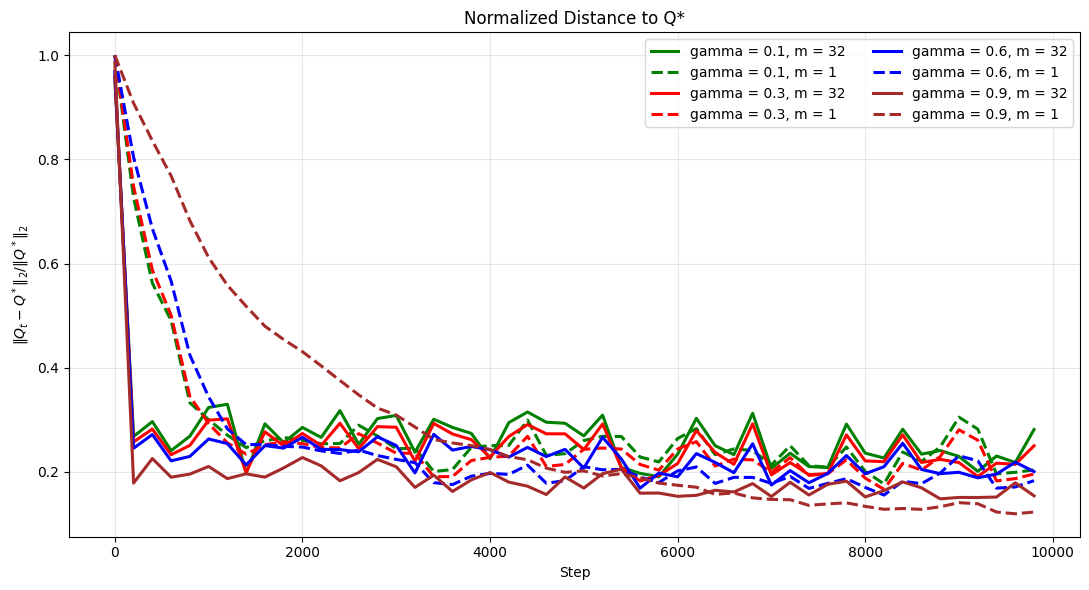

In [3]:
norm_runs = {}
qstar_norms = {}

for gamma in ALL_GAMMAS:
    Q_star = load_qstar(gamma)
    qnorm = np.linalg.norm(Q_star)

    if qnorm < 1e-12:
        raise ValueError(f"||Q*|| too small for gamma={gamma}")

    qstar_norms[gamma] = qnorm
    norm_runs[gamma] = {}

    for m in [BASELINE_LONG, BATCH_LONG]:
        curves = []

        for seed in SEEDS:
            path = ql_file(QL_LONG_RUNS_DIR, gamma, m, seed)

            if FORCE_RERUN or not os.path.exists(path):
                runner.run_uniform_batch(
                    ENV_NAME,
                    map_name=MAP_NAME,
                    slippery=SLIPPERY,
                    seed=seed,
                    steps=LONG_STEPS,
                    batch_size=m,
                    samples_per_pair=SAMPLES_PER_PAIR,
                    alpha=ALPHA,
                    gamma=gamma,
                    Q_star=Q_star,
                    alpha_mode=ALPHA_MODE,
                    alpha_beta=ALPHA_BETA,
                    alpha_tau=ALPHA_TAU,
                    use_exact_bellman=USE_EXACT_BELLMAN,
                    out_root=QL_LONG_RUNS_DIR,
                )

            data = np.load(path, allow_pickle=True)
            dist = np.asarray(data["dist_to_Qstar"], dtype=float)
            curves.append(dist / qnorm)

        arr = np.stack(curves, axis=0)
        norm_runs[gamma][m] = {
            "mean": arr.mean(axis=0),
            "std": arr.std(axis=0),
        }

plt.figure(figsize=(11, 6))

for gamma in ALL_GAMMAS:
    for m, linestyle in [(BATCH_LONG, "-"), (BASELINE_LONG, "--")]:
        y = norm_runs[gamma][m]["mean"]
        x = np.arange(len(y))

        plt.plot(
            x[::STRIDE_LONG],
            y[::STRIDE_LONG],
            color=COLOR_MAP_GAMMA[gamma],
            linestyle=linestyle,
            linewidth=2.2,
            label=f"gamma = {gamma}, m = {m}",
        )

plt.title("Normalized Distance to Q*")
plt.xlabel("Step")
plt.ylabel(r"$\|Q_t - Q^*\|_2 / \|Q^*\|_2$")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

filename = os.path.join(FIGURES_DIR, "ql_gamma_comparison_normalized.png")
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()